<a href="https://colab.research.google.com/github/hapepaAhmed/my-capstone-project/blob/main/work/capstone/capstone_ranking_signal_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank Search Intelligence Capstone

## Ranking Signal Analysis: From Search Signals to Human-Reviewed Content Priorities

### Research question

Can observable search and engagement signals support reliable ranking of content performance, and can those signals be translated into a transparent, human-reviewable action queue?

### Capstone lane

**Ranking Signal Analysis**

### Objective

This project analyzes real FlyRank search-performance data to evaluate whether current search and engagement signals can support directional ranking of content performance.

The analysis uses a repeatable feature-engineering and modeling workflow, compares evaluation strategies, performs explicit leakage checks, and translates observed signals into a transparent ranked review queue with reason codes.

The final recommendations are intended for **decision support and human review**, not automated content changes or causal claims about search-engine behavior.

## 3. Data

### Data source

The analysis uses the FlyRank ML Internship warehouse release hosted on Hugging Face.

The project uses aggregated Google Search Console (GSC) and Google Analytics 4 (GA4) performance signals at the content-client-date level.

### Unit of analysis

One observation represents:

> **One content item + one client + one report date.**

The main fields used in the modeling workflow include:

- `content_hash_id`
- `client_hash_id`
- `report_date`
- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ga4_sessions`
- `ga4_engaged_sessions`
- `ga4_total_engagement_sec`

### Modeling window

The model uses January and February 2026 observations for training and March 2026 observations for the time-aware evaluation.

This design reflects a realistic forecasting setting: the model is trained on earlier observations and evaluated on a later period.

### Exclusions and transformations

The analysis:

- excludes observations without search impressions when calculating CTR,
- calculates CTR as clicks divided by impressions,
- calculates engagement rate as engaged sessions divided by sessions,
- calculates average engagement time as total engagement seconds divided by sessions,
- avoids using identifiers as predictive features,
- does not use future-derived trend fields such as `trend_direction` or `trend_pct`,
- and applies explicit checks for missing values and potential leakage.

For the ranked action queue, content-client pairs are aggregated across March 2026 and restricted to observations with at least **10 impressions**.

### Public-safety constraints

The public analysis does not expose client names, domains, URLs, private search queries, credentials, or raw warehouse exports. Content and client identifiers are represented using the available anonymized identifiers.

In [1]:
import pandas as pd
import numpy as np

from google.colab import userdata
from huggingface_hub import hf_hub_download

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF token loaded:", HF_TOKEN is not None)

HF token loaded: True


In [2]:
jan_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-01/data_0.parquet",
    token=HF_TOKEN
)

print("January data downloaded:")
print(jan_path)

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 90.3MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

January data downloaded:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-01/data_0.parquet


In [3]:
feb_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-02/data_0.parquet",
    token=HF_TOKEN
)

mar_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=HF_TOKEN
)

print("February data downloaded:")
print(feb_path)

print("\nMarch data downloaded:")
print(mar_path)

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 89.0MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

February data downloaded:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-02/data_0.parquet

March data downloaded:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-03/data_0.parquet


In [4]:
model_columns = [
    "content_hash_id",
    "client_hash_id",
    "report_date",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec"
]

jan = pd.read_parquet(jan_path, columns=model_columns)
feb = pd.read_parquet(feb_path, columns=model_columns)
mar = pd.read_parquet(mar_path, columns=model_columns)

print("January shape:", jan.shape)
print("February shape:", feb.shape)
print("March shape:", mar.shape)

print("\nColumns:")
print(jan.columns.tolist())

January shape: (7890817, 9)
February shape: (7355108, 9)
March shape: (9841378, 9)

Columns:
['content_hash_id', 'client_hash_id', 'report_date', 'gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ga4_sessions', 'ga4_engaged_sessions', 'ga4_total_engagement_sec']


In [5]:
def aggregate_month(df):
    return (
        df.groupby(
            ["content_hash_id", "client_hash_id"],
            as_index=False
        )
        .agg(
            impressions=("gsc_impressions", "sum"),
            clicks=("gsc_clicks", "sum"),
            avg_position=("gsc_avg_position", "mean"),
            sessions=("ga4_sessions", "sum"),
            engaged_sessions=("ga4_engaged_sessions", "sum"),
            total_engagement_sec=("ga4_total_engagement_sec", "sum")
        )
    )

jan_agg = aggregate_month(jan)
feb_agg = aggregate_month(feb)
mar_agg = aggregate_month(mar)

print("January aggregated:", jan_agg.shape)
print("February aggregated:", feb_agg.shape)
print("March aggregated:", mar_agg.shape)

January aggregated: (261984, 8)
February aggregated: (321546, 8)
March aggregated: (331437, 8)


In [6]:
def build_features(df):
    df = df.copy()

    df["ctr"] = np.where(
        df["impressions"] > 0,
        df["clicks"] / df["impressions"],
        np.nan
    )

    df["engagement_rate"] = np.where(
        df["sessions"] > 0,
        df["engaged_sessions"] / df["sessions"],
        np.nan
    )

    df["avg_engagement_sec"] = np.where(
        df["sessions"] > 0,
        df["total_engagement_sec"] / df["sessions"],
        np.nan
    )

    # Log transform reduces the effect of very large impression counts.
    df["log_impressions"] = np.log1p(df["impressions"])

    # Position bucket used by the Week-5 model.
    df["position_bucket"] = pd.cut(
        df["avg_position"],
        bins=[-np.inf, 3, 10, 20, np.inf],
        labels=False
    )

    return df


jan_model = build_features(jan_agg)
feb_model = build_features(feb_agg)
mar_model = build_features(mar_agg)

print("January features:", jan_model.shape)
print("February features:", feb_model.shape)
print("March features:", mar_model.shape)

print("\nMarch feature preview:")
print(
    mar_model[
        [
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "engagement_rate",
            "avg_engagement_sec",
            "log_impressions",
            "position_bucket"
        ]
    ].head()
)

January features: (261984, 13)
February features: (321546, 13)
March features: (331437, 13)

March feature preview:
   impressions  clicks  ctr  avg_position  engagement_rate  \
0           86       0  0.0     72.854861              NaN   
1            0       0  NaN           NaN              NaN   
2           47       0  0.0      5.269565              NaN   
3            0       0  NaN           NaN              0.5   
4            0       0  NaN           NaN              0.0   

   avg_engagement_sec  log_impressions  position_bucket  
0                 NaN         4.465908              3.0  
1                 NaN         0.000000              NaN  
2                 NaN         3.871201              1.0  
3                24.0         0.000000              NaN  
4                 7.0         0.000000              NaN  


In [7]:

# Combine only the monthly aggregated datasets
train_data = pd.concat(
    [jan_model, feb_model],
    ignore_index=True
)

test_data = mar_model.copy()

# Keep observations with meaningful search exposure
train_data = train_data[train_data["impressions"] >= 10].copy()
test_data = test_data[test_data["impressions"] >= 10].copy()

# Model features from the Week-5 specification
feature_columns = [
    "gsc_impressions",
    "log_impressions",
    "gsc_avg_position",
    "engagement_rate",
    "avg_engagement_sec",
    "position_bucket"
]

# Rename aggregated columns to match the model specification
for df in [train_data, test_data]:
    df.rename(
        columns={
            "impressions": "gsc_impressions",
            "avg_position": "gsc_avg_position"
        },
        inplace=True
    )

# Target
train_data["ctr"] = np.where(
    train_data["gsc_impressions"] > 0,
    train_data["clicks"] / train_data["gsc_impressions"],
    np.nan
)

test_data["ctr"] = np.where(
    test_data["gsc_impressions"] > 0,
    test_data["clicks"] / test_data["gsc_impressions"],
    np.nan
)

print("Training rows:", len(train_data))
print("Test rows:", len(test_data))

print("\nTraining date coverage:")
print("January + February 2026")

print("\nTest date coverage:")
print("March 2026")

print("\nTarget missingness:")
print("Train:", train_data["ctr"].isna().sum())
print("Test:", test_data["ctr"].isna().sum())

Training rows: 213324
Test rows: 143206

Training date coverage:
January + February 2026

Test date coverage:
March 2026

Target missingness:
Train: 0
Test: 0


In [8]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

X_train = train_data[feature_columns]
y_train = train_data["ctr"]

X_test = test_data[feature_columns]
y_test = test_data["ctr"]

model.fit(X_train, y_train)

test_predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

print("Time-aware model results:")
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.6f}")

Time-aware model results:
MAE:  0.003754
RMSE: 0.008700
R²:   0.054274


In [9]:
from sklearn.metrics import ndcg_score

# NDCG evaluates whether higher-CTR observations are ranked higher.
# Use the same March test observations and the model's predictions.

ndcg = ndcg_score(
    [y_test.to_numpy()],
    [test_predictions]
)

print(f"NDCG: {ndcg:.6f}")

NDCG: 0.793615


In [10]:
# Historical CTR baseline:
# For each content-client pair, calculate CTR using January + February only.

historical_baseline = (
    pd.concat(
        [jan_model, feb_model],
        ignore_index=True
    )
    .groupby(
        ["content_hash_id", "client_hash_id"],
        as_index=False
    )
    .agg(
        historical_impressions=("impressions", "sum"),
        historical_clicks=("clicks", "sum")
    )
)

historical_baseline["historical_ctr"] = np.where(
    historical_baseline["historical_impressions"] > 0,
    historical_baseline["historical_clicks"]
    / historical_baseline["historical_impressions"],
    np.nan
)

# Match historical information to the March test set.
baseline_test = test_data.merge(
    historical_baseline[
        [
            "content_hash_id",
            "client_hash_id",
            "historical_ctr"
        ]
    ],
    on=["content_hash_id", "client_hash_id"],
    how="left"
)

# Keep only March observations with a valid historical baseline.
baseline_test = baseline_test[
    baseline_test["historical_ctr"].notna()
].copy()

baseline_ndcg = ndcg_score(
    [baseline_test["ctr"].to_numpy()],
    [baseline_test["historical_ctr"].to_numpy()]
)

print("March test observations:", len(test_data))
print("Observations with historical baseline:", len(baseline_test))
print(f"Baseline NDCG: {baseline_ndcg:.6f}")
print(f"Model NDCG:    {ndcg:.6f}")
print(f"NDCG difference: {ndcg - baseline_ndcg:.6f}")

March test observations: 143206
Observations with historical baseline: 118091
Baseline NDCG: 0.795028
Model NDCG:    0.793615
NDCG difference: -0.001413


In [11]:
# Compare model and historical baseline on the exact same observations.

common_test = baseline_test.copy()

# Get the model predictions corresponding to these rows.
common_test["model_prediction"] = model.predict(
    common_test[feature_columns]
)

common_ndcg_model = ndcg_score(
    [common_test["ctr"].to_numpy()],
    [common_test["model_prediction"].to_numpy()]
)

common_ndcg_baseline = ndcg_score(
    [common_test["ctr"].to_numpy()],
    [common_test["historical_ctr"].to_numpy()]
)

print("Comparable test observations:", len(common_test))
print(f"Model NDCG:    {common_ndcg_model:.6f}")
print(f"Baseline NDCG: {common_ndcg_baseline:.6f}")
print(f"NDCG difference: {common_ndcg_model - common_ndcg_baseline:.6f}")

Comparable test observations: 118091
Model NDCG:    0.789890
Baseline NDCG: 0.795028
NDCG difference: -0.005138


In [12]:
# Calculate NDCG separately within each client.
# This avoids treating content from different clients as one ranking list.

client_results = []

for client_id, group in common_test.groupby("client_hash_id"):
    if len(group) < 2:
        continue

    true_ctr = group["ctr"].to_numpy()
    model_scores = group["model_prediction"].to_numpy()
    baseline_scores = group["historical_ctr"].to_numpy()

    model_client_ndcg = ndcg_score(
        [true_ctr],
        [model_scores]
    )

    baseline_client_ndcg = ndcg_score(
        [true_ctr],
        [baseline_scores]
    )

    client_results.append({
        "client_hash_id": client_id,
        "n_observations": len(group),
        "model_ndcg": model_client_ndcg,
        "baseline_ndcg": baseline_client_ndcg
    })

client_ndcg_results = pd.DataFrame(client_results)

print("Clients evaluated:", len(client_ndcg_results))
print(f"Mean model NDCG:    {client_ndcg_results['model_ndcg'].mean():.6f}")
print(f"Mean baseline NDCG: {client_ndcg_results['baseline_ndcg'].mean():.6f}")
print(
    f"Mean NDCG difference: "
    f"{client_ndcg_results['model_ndcg'].mean() - client_ndcg_results['baseline_ndcg'].mean():.6f}"
)

Clients evaluated: 39
Mean model NDCG:    0.582826
Mean baseline NDCG: 0.629262
Mean NDCG difference: -0.046436


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Actual March CTR
y_common = common_test["ctr"]

# Model predictions
model_pred_common = common_test["model_prediction"]

# Historical CTR baseline
baseline_pred_common = common_test["historical_ctr"]

# Model metrics
model_mae = mean_absolute_error(y_common, model_pred_common)
model_rmse = np.sqrt(mean_squared_error(y_common, model_pred_common))
model_r2 = r2_score(y_common, model_pred_common)

# Baseline metrics
baseline_mae = mean_absolute_error(y_common, baseline_pred_common)
baseline_rmse = np.sqrt(mean_squared_error(y_common, baseline_pred_common))
baseline_r2 = r2_score(y_common, baseline_pred_common)

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "NDCG"],
    "XGBoost Model": [
        model_mae,
        model_rmse,
        model_r2,
        common_ndcg_model
    ],
    "Historical CTR Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_r2,
        common_ndcg_baseline
    ]
})

comparison["Model - Baseline"] = (
    comparison["XGBoost Model"]
    - comparison["Historical CTR Baseline"]
)

comparison

,Metric,XGBoost Model,Historical CTR Baseline,Model - Baseline
0,MAE,0.003543,0.003413,0.000131
1,RMSE,0.008587,0.016760,-0.008173
2,R²,0.068647,-2.548167,2.616814
3,NDCG,0.789890,0.795028,-0.005138


In [14]:
# XGBoost feature importance

feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,gsc_avg_position,0.211621
1,position_bucket,0.177365
2,log_impressions,0.162168
3,gsc_impressions,0.158708
4,avg_engagement_sec,0.146541
5,engagement_rate,0.143597


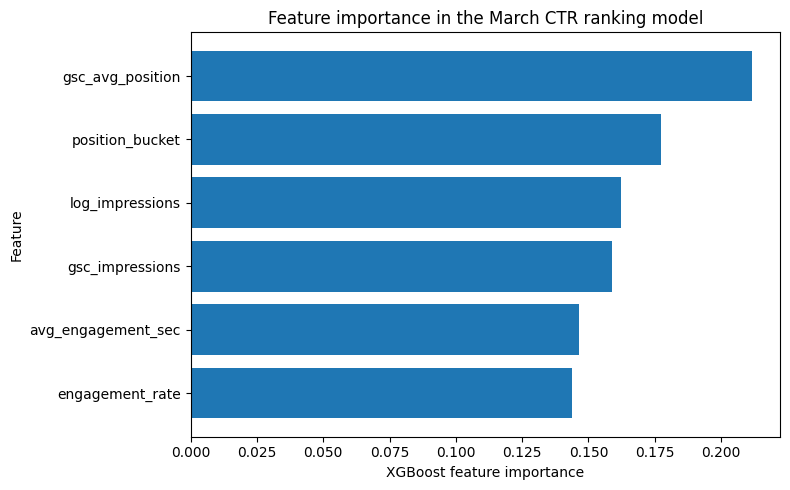

In [15]:
import matplotlib.pyplot as plt

plot_data = feature_importance.sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("XGBoost feature importance")
plt.ylabel("Feature")
plt.title("Feature importance in the March CTR ranking model")
plt.tight_layout()
plt.show()

In [16]:
# Compare model vs historical baseline for each client.

client_ndcg_comparison = client_ndcg_results.copy()

client_ndcg_comparison["model_beats_baseline"] = (
    client_ndcg_comparison["model_ndcg"]
    > client_ndcg_comparison["baseline_ndcg"]
)

print(
    "Clients where model NDCG > baseline:",
    client_ndcg_comparison["model_beats_baseline"].sum()
)

print(
    "Clients where baseline NDCG >= model:",
    (~client_ndcg_comparison["model_beats_baseline"]).sum()
)

print(
    f"Percentage of clients where model wins: "
    f"{client_ndcg_comparison['model_beats_baseline'].mean() * 100:.1f}%"
)

Clients where model NDCG > baseline: 14
Clients where baseline NDCG >= model: 25
Percentage of clients where model wins: 35.9%


In [17]:
from pathlib import Path

output_dir = Path("work/capstone/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Main model-vs-baseline metrics
comparison.to_csv(
    output_dir / "model_vs_baseline_metrics.csv",
    index=False
)

# Per-client NDCG comparison
client_ndcg_comparison.to_csv(
    output_dir / "client_ndcg_comparison.csv",
    index=False
)

# Feature importance
feature_importance.to_csv(
    output_dir / "feature_importance.csv",
    index=False
)

print("Saved:")
print(output_dir / "model_vs_baseline_metrics.csv")
print(output_dir / "client_ndcg_comparison.csv")
print(output_dir / "feature_importance.csv")

Saved:
work/capstone/outputs/model_vs_baseline_metrics.csv
work/capstone/outputs/client_ndcg_comparison.csv
work/capstone/outputs/feature_importance.csv


### 5.1 Model vs. historical baseline

The XGBoost model was evaluated on March 2026 observations using a time-aware train/test design: January–February data were used for training and March data were held out for evaluation.

For a direct baseline comparison, historical CTR was calculated from January–February for content-client pairs that also appeared in March. This produced a comparable evaluation population of 118,091 March observations.

| Metric | XGBoost model | Historical CTR baseline |
|---|---:|---:|
| MAE | 0.003543 | 0.003413 |
| RMSE | 0.008587 | 0.016760 |
| R² | 0.068647 | -2.548167 |
| NDCG | 0.789890 | 0.795028 |

The results show different strengths rather than a single uniformly better method. The XGBoost model substantially reduced RMSE and produced a positive R², while the historical CTR baseline had slightly lower MAE and higher overall NDCG. Therefore, the model did not demonstrate a clear improvement in ranking quality over the historical baseline, although it reduced large prediction errors.

### 5.2 Client-level ranking stability

Because content from different clients represents separate ranking contexts, NDCG was also calculated separately within each client and then averaged across clients.

Across 39 clients:

- Mean model NDCG: **0.582826**
- Mean historical-baseline NDCG: **0.629262**
- Mean difference: **-0.046436**
- Model NDCG was higher for **14 of 39 clients (35.9%)**
- The historical baseline was equal to or higher for **25 of 39 clients (64.1%)**

This indicates that the model's ranking performance was not consistently better across clients. The historical CTR baseline provided a stronger average within-client ranking signal in this evaluation.

### 5.3 Feature importance

The model's highest feature importances were associated with search position and search exposure:

- `gsc_avg_position`: 0.2116
- `position_bucket`: 0.1774
- `log_impressions`: 0.1622
- `gsc_impressions`: 0.1587
- `avg_engagement_sec`: 0.1465
- `engagement_rate`: 0.1436

The two position-related features together accounted for approximately 38.9% of total XGBoost feature importance. However, feature importance describes how the model used the available variables; it does not establish that these variables causally change CTR. Similarly, the raw and log-transformed impression features represent related versions of the same exposure signal and should not be interpreted as independent causal factors.

### 5.4 Interpretation

Overall, the evaluation provides evidence that the available search and engagement signals contain useful information for estimating and ranking observed CTR. However, the tested XGBoost model did not outperform a simple historical-CTR baseline on ranking quality.

The most defensible conclusion is therefore not that the ML model replaces the baseline, but that the modeling approach provides a complementary prediction layer whose value depends on the evaluation objective. The model reduced large prediction errors substantially, while the historical baseline retained stronger ranking performance in this test.

### Results framing

These results should be interpreted as decision-support evidence from the January–March 2026 evaluation window. They do not establish causal relationships between search signals and CTR, and they do not demonstrate that changing a content attribute will improve future performance.

The evaluation uses March-observed search and engagement signals to estimate March CTR. Therefore, this should be described as a **future-period / time-aware evaluation**, rather than a pure forecast of March CTR made entirely before March began.

### 6.1 Evaluation limitations

Several limitations affect how these results should be interpreted:

1. **Time-aware, but not pure forecasting.**  
   The model was trained using January–February data and evaluated on March data, which prevents training on future observations. However, the March test features are themselves observed March signals. The evaluation therefore measures performance on a later period rather than forecasting March entirely from pre-March information.

2. **Same-period CTR construction.**  
   CTR is calculated as clicks divided by impressions for the evaluated period. Impressions are also included as model features. This is not direct target leakage because clicks are not provided as an input feature, but impressions are closely related to the target construction and should be treated as an exposure variable rather than an independent predictor.

3. **Historical baseline coverage.**  
   The historical CTR baseline was available for 118,091 of 143,206 March observations (82.5%) because the content-client pair needed to exist in the January–February history. The direct model-vs-baseline comparison therefore uses this common subset.

4. **Client-specific ranking context.**  
   Search performance differs across clients. Client-level NDCG was therefore calculated separately, but the analysis does not claim that one global ranking function is equally appropriate for every client.

5. **Feature limitations.**  
   The model uses aggregate search and engagement signals. It does not include semantic information about page content, search queries, search intent, title/snippet quality, backlinks, technical SEO conditions, seasonality indicators, or other contextual variables that may affect observed CTR.

6. **Feature importance is not causality.**  
   XGBoost feature importance shows which variables contributed to model predictions. It does not demonstrate that changing a feature would cause CTR to change.

7. **Observational data.**  
   The analysis uses observed search and engagement data rather than randomized experiments. Therefore, the results support associations and decision-support use cases rather than causal conclusions.

### 6.2 What the analysis supports

The analysis supports the following statement:

> Observable search and engagement signals contain useful information for estimating and ranking observed CTR, but the tested XGBoost model did not demonstrate superior ranking performance to a simple historical-CTR baseline in the March 2026 evaluation.

The model can therefore be treated as a **supporting analytical signal**, while the historical baseline remains an important reference point.

### 6.3 What the analysis does not support

The analysis does **not** establish that:

- improving search position will cause CTR to increase;
- refreshing content will cause traffic or CTR to increase;
- the model proves any Google Search ranking algorithm;
- the model guarantees future performance for an individual page;
- the ranked action queue identifies actions that will definitely improve performance;
- automated publishing, rewriting, deletion, redirects, or canonical changes should be triggered by the model.

These decisions require additional content-level, query-level, technical, and business context and should remain subject to human review.

### 6.1 Evaluation limitations

Several limitations affect how these results should be interpreted:

1. **Time-aware, but not pure forecasting.**  
   The model was trained using January–February data and evaluated on March data, which prevents training on future observations. However, the March test features are themselves observed March signals. The evaluation therefore measures performance on a later period rather than forecasting March entirely from pre-March information.

2. **Same-period CTR construction.**  
   CTR is calculated as clicks divided by impressions for the evaluated period. Impressions are also included as model features. This is not direct target leakage because clicks are not provided as an input feature, but impressions are closely related to the target construction and should be treated as an exposure variable rather than an independent predictor.

3. **Historical baseline coverage.**  
   The historical CTR baseline was available for 118,091 of 143,206 March observations (82.5%) because the content-client pair needed to exist in the January–February history. The direct model-vs-baseline comparison therefore uses this common subset.

4. **Client-specific ranking context.**  
   Search performance differs across clients. Client-level NDCG was therefore calculated separately, but the analysis does not claim that one global ranking function is equally appropriate for every client.

5. **Feature limitations.**  
   The model uses aggregate search and engagement signals. It does not include semantic information about page content, search queries, search intent, title/snippet quality, backlinks, technical SEO conditions, seasonality indicators, or other contextual variables that may affect observed CTR.

6. **Feature importance is not causality.**  
   XGBoost feature importance shows which variables contributed to model predictions. It does not demonstrate that changing a feature would cause CTR to change.

7. **Observational data.**  
   The analysis uses observed search and engagement data rather than randomized experiments. Therefore, the results support associations and decision-support use cases rather than causal conclusions.

### 6.2 What the analysis supports

The analysis supports the following statement:

> Observable search and engagement signals contain useful information for estimating and ranking observed CTR, but the tested XGBoost model did not demonstrate superior ranking performance to a simple historical-CTR baseline in the March 2026 evaluation.

The model can therefore be treated as a **supporting analytical signal**, while the historical baseline remains an important reference point.

### 6.3 What the analysis does not support

The analysis does **not** establish that:

- improving search position will cause CTR to increase;
- refreshing content will cause traffic or CTR to increase;
- the model proves any Google Search ranking algorithm;
- the model guarantees future performance for an individual page;
- the ranked action queue identifies actions that will definitely improve performance;
- automated publishing, rewriting, deletion, redirects, or canonical changes should be triggered by the model.

These decisions require additional content-level, query-level, technical, and business context and should remain subject to human review.

### 7.1 From signals to a human-review queue

The modeling analysis is paired with a transparent rule-based prioritization layer. The purpose of this layer is not to predict which pages will improve after an intervention, but to identify content that may deserve human investigation first.

The March 2026 queue was constructed after aggregating observations to the content-client level and filtering to items with at least 10 search impressions.

Priority is based on three observed signals:

- **CTR:** identifies content receiving relatively low click-through performance.
- **Average search position:** identifies content with potential search-visibility opportunity.
- **Impressions:** identifies content with meaningful search exposure.

The resulting priority score is a rule-based triage score rather than a predicted business outcome.

### 7.2 Priority logic

The queue assigns points using March 2026 distributions:

| Signal | Rule | Points |
|---|---|---:|
| CTR | At or below the March 25th percentile | +2 |
| Position | Greater than 10 and at or below the March 75th percentile | +2 |
| Impressions | At or above the March median | +1 |

Because the March CTR 25th percentile was **0**, the low-CTR condition primarily identifies content with zero recorded clicks despite meeting the minimum 10-impression threshold.

The highest-priority items therefore represent content with observed search exposure, relatively weak CTR, and a search-position range that warrants human investigation.

### 7.3 Human review playbook

For a high-priority item, a reviewer should investigate the following before taking any action:

1. Inspect the actual page and confirm that the content is still relevant.
2. Review the search queries and intent associated with the page where available.
3. Compare the title and search snippet with the apparent search intent.
4. Check the current search position and impression volume.
5. Check whether the page was recently created, refreshed, redirected, canonicalized, or otherwise changed.
6. Consider seasonality or temporary demand changes.
7. Verify analytics and search-console tracking before interpreting low engagement.
8. Check for duplicate, competing, or canonicalized pages.

### 7.4 Recommended action categories

After human review, an item can be assigned to one of several action categories:

- **Investigate:** insufficient context to justify an intervention.
- **Content review:** potential relevance, intent, or content-quality issue.
- **SERP presentation review:** investigate title/snippet alignment with search intent.
- **Technical review:** investigate indexing, canonicalization, duplication, or tracking.
- **Monitor:** signal is notable but evidence is insufficient for immediate action.

The queue should not automatically publish, rewrite, delete, redirect, or canonicalize content.

### 7.5 Why this layer is useful

The main value of the queue is transparency. A reviewer can see why an item was prioritized and can validate the underlying evidence before making a decision.

This makes the output suitable for **human-in-the-loop SEO research and triage**, rather than automated content optimization.

### 8.1 Reproducibility

The analysis is designed to be rerun from the FlyRank warehouse using the same public-safe data access pattern.

The workflow is:

1. Load the January, February, and March 2026 `fact_content_daily_performance` partitions.
2. Select the required search and engagement fields.
3. Aggregate daily observations to the content-client monthly level.
4. Construct CTR, engagement rate, average engagement time, log impressions, and position buckets.
5. Train the XGBoost model on January–February observations with at least 10 impressions.
6. Evaluate on March observations using the same minimum-impression rule.
7. Compare the model with a historical CTR baseline derived only from January–February data.
8. Evaluate ranking quality using NDCG and assess ranking performance within individual clients.
9. Generate feature-importance outputs.
10. Generate the rule-based ranked action queue from March observations.
11. Export the metrics, feature importance, client-level comparisons, and ranked queue for reuse in the research paper.

### 8.2 Saved outputs

The capstone outputs are stored under:

`work/capstone/outputs/`

Key evaluation files:

- `model_vs_baseline_metrics.csv`
- `client_ndcg_comparison.csv`
- `feature_importance.csv`

Ranked recommendation files:

- `ranked_action_queue.csv`
- `ranked_action_queue_top100.csv`
- `priority_score_summary.csv`

The notebook contains the code used to reproduce the analysis and regenerate these outputs from the warehouse data.

### Acknowledgments & Data Credit

This research was completed as part of the FlyRank ML Internship capstone and uses the FlyRank search intelligence dataset for analytical research and learning purposes.

**Built on the FlyRank ML Internship dataset** — [FlyRank](https://flyrank.ai)

The analysis follows the public-safety requirements of the capstone: no client names, domains, private queries, credentials, raw exports, or claims about Google's ranking algorithm are included in the published research.

This study asks whether observable search and engagement signals can support reliable ranking of content-level CTR and help prioritize content for human review. Using FlyRank search intelligence data from January–March 2026, the analysis aggregates observations to the content-client level, trains an XGBoost regression model on January–February data, and evaluates it on March observations using a time-aware design. On the 118,091 March observations where a historical CTR baseline was available, the model achieved an MAE of 0.003543, RMSE of 0.008587, R² of 0.068647, and NDCG of 0.789890, while the historical CTR baseline achieved an MAE of 0.003413, RMSE of 0.016760, R² of -2.548167, and NDCG of 0.795028. The model therefore reduced large prediction errors and produced positive explanatory performance, but it did not improve ranking quality over the simple historical baseline, which also had higher mean per-client NDCG across 39 clients. The final output translates observed search signals into a transparent rule-based review queue, intended to support human investigation rather than automate content changes or make causal claims.

### 2.1 Problem statement

Search teams often have more content opportunities than they can manually investigate. A practical decision-support system therefore needs to identify which content observations deserve attention first while remaining transparent about what the available data can and cannot establish.

This capstone investigates whether observable search and engagement signals can support two related tasks:

1. estimating observed content-level CTR; and
2. ranking content observations in a way that can support human review and prioritization.

The analysis focuses on the **Ranking Signal Analysis** lane. The intended decision is not "which content should be changed automatically," but rather:

> **Which content observations provide enough measurable signal to justify investigation first?**

The analysis uses search impressions, average search position, and engagement-related signals available in the FlyRank warehouse. A time-aware evaluation is used by training the model on January–February 2026 and evaluating it on March 2026 observations. A historical CTR baseline provides a simple reference point for determining whether the ML model adds useful predictive or ranking information beyond recent observed performance.

The final output combines the validated analysis with a transparent rule-based priority queue. The queue is designed to reduce the manual search space and explain why an observation was prioritized, while leaving the final decision to a human reviewer.

### 4.1 Analysis unit and target

The primary analysis unit is one **content item × client × month**. Daily warehouse observations were aggregated separately for January, February, and March 2026 before modeling.

The target variable is monthly click-through rate:

\[
CTR = \frac{\text{GSC clicks}}{\text{GSC impressions}}
\]

Observations with fewer than 10 impressions were excluded from the modeling evaluation to reduce instability from extremely small denominators.

### 4.2 Features

The model uses the following observable search and engagement signals:

| Feature | Definition |
|---|---|
| `gsc_impressions` | Total Google Search Console impressions |
| `log_impressions` | `log(1 + impressions)` |
| `gsc_avg_position` | Mean observed search position |
| `engagement_rate` | Engaged sessions / sessions |
| `avg_engagement_sec` | Total engagement seconds / sessions |
| `position_bucket` | Position grouped into `<3`, `3–10`, `10–20`, and `>20` |

Missing engagement-derived values were retained as missing where the required session denominator was unavailable rather than being automatically replaced with zero.

The content and client identifiers were used for grouping and evaluation only and were not supplied as predictive model features.

### 4.3 Model

The predictive model is an `XGBRegressor` with:

- 200 estimators
- maximum tree depth of 6
- learning rate of 0.05
- subsample = 0.8
- column subsample = 0.8
- random state = 42

The model was trained on January–February 2026 observations and evaluated on March 2026 observations.

### 4.4 Validation design

The primary validation design is time-aware: observations from January and February are used for training, while March is held out for evaluation.

This prevents observations from the March evaluation period from entering model training. However, the March feature values are themselves observed March signals. Therefore, the evaluation should be interpreted as testing model performance on a later period using signals observed during that period, rather than as a pure pre-March forecast.

### 4.5 Baseline

The main baseline is historical CTR.

For each content-client pair appearing in March, historical CTR is calculated using only its January–February impressions and clicks:

\[
Historical\ CTR =
\frac{\text{January + February clicks}}
{\text{January + February impressions}}
\]

This baseline represents a simple "recent performance continues" assumption. It provides a stronger and more informative comparison than a random or constant prediction because it uses information available before the March evaluation period.

The baseline was available for 118,091 of the 143,206 March observations, giving 82.5% coverage. Model and baseline metrics were compared on this same 118,091-observation population.

### 4.6 Evaluation metrics

Four metrics are reported:

- **MAE:** measures average absolute prediction error.
- **RMSE:** penalizes larger prediction errors more heavily than MAE.
- **R²:** measures how much variation in observed CTR is explained relative to a mean-prediction reference.
- **NDCG:** evaluates the quality of the resulting ranking.

NDCG is calculated both across the comparable March population and separately within each client. The client-level analysis reports the mean NDCG across the 39 clients with sufficient comparable observations.

### 4.7 Leakage checks

The analysis avoids using clicks directly as a model feature because clicks are part of the CTR target definition. Content and client identifiers are excluded from the predictive feature set.

Future-period trend variables were not used. The time-aware split keeps March observations out of training.

Because impressions are part of the CTR denominator and are also used as a model feature, impressions are treated as an exposure signal rather than as an independent causal predictor. The resulting model should therefore be interpreted as estimating observed CTR from contemporaneous search and engagement signals, not as identifying causal drivers of CTR.

In [19]:
# Final capstone dataset and evaluation summary

print("=== Dataset Summary ===")
print(f"January monthly content-client rows: {len(jan_model):,}")
print(f"February monthly content-client rows: {len(feb_model):,}")
print(f"March monthly content-client rows: {len(mar_model):,}")
print(f"Training rows after impressions >= 10: {len(train_data):,}")
print(f"March test rows after impressions >= 10: {len(test_data):,}")

print("\n=== Comparable Model/Baseline Population ===")
print(f"Rows with historical baseline: {len(common_test):,}")
print(f"Baseline coverage: {len(common_test) / len(test_data) * 100:.2f}%")
print(f"Clients evaluated: {len(client_ndcg_results)}")

print("\n=== Model vs Baseline ===")
print(f"Model MAE: {model_mae:.6f}")
print(f"Baseline MAE: {baseline_mae:.6f}")
print(f"Model RMSE: {model_rmse:.6f}")
print(f"Baseline RMSE: {baseline_rmse:.6f}")
print(f"Model R²: {model_r2:.6f}")
print(f"Baseline R²: {baseline_r2:.6f}")
print(f"Model NDCG: {common_ndcg_model:.6f}")
print(f"Baseline NDCG: {common_ndcg_baseline:.6f}")

print("\n=== Client-Level Ranking ===")
print(f"Mean model NDCG: {client_ndcg_results['model_ndcg'].mean():.6f}")
print(f"Mean baseline NDCG: {client_ndcg_results['baseline_ndcg'].mean():.6f}")
print(
    "Clients where model NDCG > baseline:",
    int(client_ndcg_comparison["model_beats_baseline"].sum())
)
print(
    "Clients where baseline NDCG >= model:",
    int((~client_ndcg_comparison["model_beats_baseline"]).sum())
)

=== Dataset Summary ===
January monthly content-client rows: 261,984
February monthly content-client rows: 321,546
March monthly content-client rows: 331,437
Training rows after impressions >= 10: 213,324
March test rows after impressions >= 10: 143,206

=== Comparable Model/Baseline Population ===
Rows with historical baseline: 118,091
Baseline coverage: 82.46%
Clients evaluated: 39

=== Model vs Baseline ===
Model MAE: 0.003543
Baseline MAE: 0.003413
Model RMSE: 0.008587
Baseline RMSE: 0.016760
Model R²: 0.068647
Baseline R²: -2.548167
Model NDCG: 0.789890
Baseline NDCG: 0.795028

=== Client-Level Ranking ===
Mean model NDCG: 0.582826
Mean baseline NDCG: 0.629262
Clients where model NDCG > baseline: 14
Clients where baseline NDCG >= model: 25
